In [25]:
import pandas as pd 
covid= pd.read_csv("z.Data/covid_data.csv")
covid.sample(n=4)
covid[:3]

,Date,Country,Total_Cases,New_Cases,Total_Deaths,New_Deaths,Recovered,Active_Cases,Serious_Critical,Tests_Per_Million,Population,Alert
0,2023-01-01,USA,99732855,14528,1073788,122,95683961,4847881,8626,1764678,338290868,Red
1,2023-01-08,India,47028214,8034,516590,51,45756120,668220,2128,339037,1405845055,Red
2,2023-01-15,Brazil,37858378,7261,723235,44,36526173,729996,3215,165300,204389564,Red


In [24]:
print(covid.columns.tolist())

['Country', 'Total_Cases', 'New_Cases', 'Total_Deaths', 'New_Deaths', 'Recovered', 'Active_Cases', 'Serious_Critical', 'Tests_Per_Million', 'Population', 'Alert']


In [32]:

from sklearn.model_selection import train_test_split 
import pandas as pd  
covid=pd.get_dummies(covid, drop_first=True)
x=covid.drop("Alert_Yellow", axis=1)  
y= covid["Alert_Yellow"]
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2,random_state=17)

In [33]:
covid[:3]

,Total_Cases,New_Cases,Total_Deaths,New_Deaths,Recovered,Active_Cases,Serious_Critical,Tests_Per_Million,Population,Date_2023-01-08,...,Country_Sweden,Country_Switzerland,Country_Thailand,Country_Turkey,Country_UAE,Country_UK,Country_USA,Country_Ukraine,Country_Vietnam,Alert_Yellow
0,99732855,14528,1073788,122,95683961,4847881,8626,1764678,338290868,False,...,False,False,False,False,False,False,True,False,False,False
1,47028214,8034,516590,51,45756120,668220,2128,339037,1405845055,True,...,False,False,False,False,False,False,False,False,False,False
2,37858378,7261,723235,44,36526173,729996,3215,165300,204389564,False,...,False,False,False,False,False,False,False,False,False,False


### OKay Then ,  
#### What is ROC and AUC, why is needed, How it is used ? 
 - Roc curve are a comparison btw A model's True Positive vs. False positive
   rate. 
1. True Pos. = model pred. 1 whereas truth is 1 
2. False Pos. = model pred. 1 whereas truth is 0 

In [34]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(x_train, y_train) 
y_probs= model.predict_proba(x_test) 
y_probs[:10]  

array([[0.28, 0.72],
       [0.93, 0.07],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.  , 1.  ],
       [0.01, 0.99],
       [0.  , 1.  ],
       [0.01, 0.99],
       [0.  , 1.  ]])

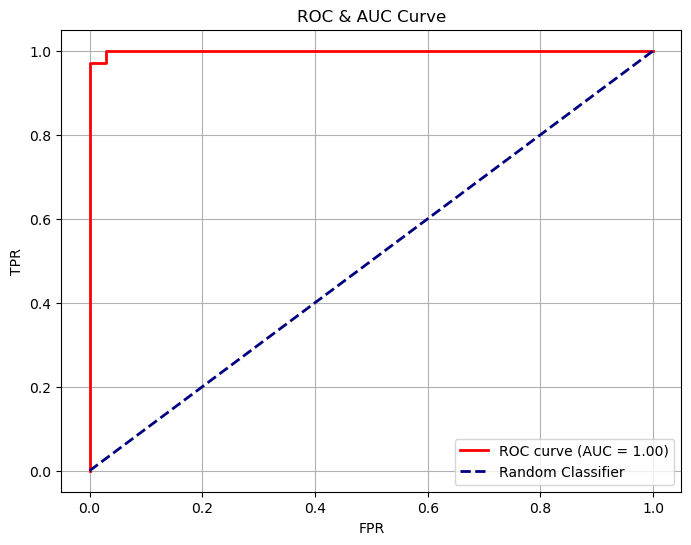

AUC Score means Area under the curve: 0.999


In [60]:
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt 
y_pos_probs= y_probs[:,1]
fpr, tpr, thred=roc_curve(y_test, y_pos_probs)
AUC= auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {AUC:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC & AUC Curve')
plt.legend(loc="lower right")
plt.grid(True) 
plt.show()

print(f"AUC Score means Area under the curve: {AUC:.3f}")

In [59]:
roc_auc_score(y_test, y_pos_probs)

np.float64(0.9991022331949275)

In [5]:
from sklearn.linear_model import LinearRegression

X = data[['firing_rate', 'num_synapses', 'resting_potential']]
y = data['power']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

neuron = LinearRegression()
neuron.fit(X_train, y_train)

print("Weights:", neuron.coef_)
print("Bias:", neuron.intercept_)
print("Train R^2:", neuron.score(X_train, y_train))
print("Test R^2:", neuron.score(X_test, y_test))